## Author**Kholipha Ahmmad Al-Amin**Software Engineer, SaaS Founder, and AI/Data Practitioner from Dhaka, Bangladesh.Portfolio: https://kholipha-ahmmad-al-amin.equisaas-bd.comGitHub: https://github.com/kholipha-ahmmad-al-aminLinkedIn: https://www.linkedin.com/in/kholipha-ahmmad-al-amin


# Dengue Outbreak Forecasting with Socio-Climate Data

## Student Information
- **Student Name:** Md. Maruf Ahammad Bhuiyan
- **Department:** Computer Science and Engineering
- **University:** Atish Dipankar University of Science & Technology

## Supervisor Information
- **Supervisor Name:** Rafid Mahmud Haque

## Target Defense
- **Summer 2026**

---

## Abstract

This notebook presents a complete, defense-ready workflow for forecasting dengue outbreak risk in Bangladesh using historical dengue case data and district-level climate data. The design is practical for Google Colab and is written so that a student, supervisor, or examiner can read it from top to bottom and clearly understand what is happening at each stage.

The notebook uses two main data sources:

1. A Bangladesh district-wise dengue case dataset from Kaggle.
2. Daily climate variables from the NASA POWER Daily Point API.

The workflow covers:

- project setup,
- dataset acquisition,
- careful preprocessing,
- climate-data fetching,
- feature engineering,
- multi-model training,
- model comparison,
- artifact saving,
- high-resolution figure export,
- and a standalone Gradio deployment cell.

---

## Exact Data Sources

### Dengue case dataset
**Kaggle dataset page**  
https://www.kaggle.com/datasets/shampabanik12/district-wise-dengue-dataset-for-bangladesh

**Dataset notes from the page**
- District
- Month
- Patients

The page preview shows that the field named **Month** actually contains date-like values such as `27/8/19`, so this notebook explicitly converts that column into a proper date field during preprocessing.

### Climate data source
**NASA POWER Daily Point API documentation**  
https://power.larc.nasa.gov/docs/services/api/temporal/daily/

This API provides analysis-ready daily climate data for specific geographic coordinates, which is suitable for district-level approximation in Bangladesh.

---

## Citations

- **Shampa Banik12.** *District wise Dengue dataset for Bangladesh*. Kaggle.  
  Dataset page: https://www.kaggle.com/datasets/shampabanik12/district-wise-dengue-dataset-for-bangladesh

- **NASA POWER Project.** *Daily Point API Documentation*. NASA POWER.  
  Documentation page: https://power.larc.nasa.gov/docs/services/api/temporal/daily/

---

## Important Research Note

This notebook is designed to be academically honest and not misleading.

- The dengue case data comes from a real public Kaggle dataset.
- The climate data comes from a real NASA API.
- The notebook **does not falsely claim** that official socioeconomic variables are already included.
- The title uses the phrase **socio-climate** because district identity and historical case behavior are treated as contextual structured predictors, but this baseline system is primarily **climate plus epidemiological-history driven**.




## Overview of the full workflow

We will move through this project in a very natural order:

1. **Set up the environment and Drive folders**
2. **Download or load the dengue dataset**
3. **Clean the dengue case data carefully**
4. **Fetch climate data from NASA POWER**
5. **Merge the datasets by district and date**
6. **Engineer lagged and rolling features**
7. **Create an outbreak target**
8. **Train several models**
9. **Compare them with both full-scale and zoomed plots**
10. **Save the best pipeline and evaluation outputs**
11. **Launch a standalone Gradio interface**

This ordering makes the notebook easy to explain in a defense and easy to reuse later.


In [1]:

# 1. Environment setup and Drive configuration


from google.colab import drive
drive.mount('/content/drive')

!pip -q install pandas numpy scikit-learn matplotlib seaborn requests kagglehub joblib gradio==4.44.1 gradio_client==1.3.0

import os
import re
import json
import warnings
import requests
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path('/content/drive/MyDrive/Dengue_Forecasting_Project_Adust')
DATA_DIR = PROJECT_ROOT / 'data'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
FIG_DIR = PROJECT_ROOT / 'figures'
REPORT_DIR = PROJECT_ROOT / 'reports'

for p in [DATA_DIR, ARTIFACT_DIR, FIG_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Data dir     :", DATA_DIR)
print("Artifacts    :", ARTIFACT_DIR)
print("Figures      :", FIG_DIR)
print("Reports      :", REPORT_DIR)


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 12.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.68.0 requires websockets<17.0,>=13.0.0, but you have websockets 12.0 which is incompatible.
yfinance 0.2.66 requires websockets>=13.0, but you have websockets 12.0 which is incompatible.
dataproc-spark-connect 1.1.0 requires websockets>=14.0, but you have websockets 12.0 which is incompatible.
google-adk 1.29.0 requires websockets<16.0.0,>=15.0.1, but you have websockets 12.0 which is incompatible.
Project root : /content/drive/MyDrive/Dengue_Forecasting_Projec


## Why the dataset acquisition step is written carefully

Public Kaggle datasets are convenient, but notebook users often run into confusion because some tools require authentication while others behave differently for public datasets.

To avoid confusion, this notebook uses the exact `kagglehub` method:

```python
import kagglehub
path = kagglehub.dataset_download("shampabanik12/district-wise-dengue-dataset-for-bangladesh")
```

Then it searches the downloaded directory for the CSV file, saves a reusable raw copy into Drive, and continues from there. If the raw file is already cached in Drive, the notebook simply reuses it.


In [2]:

# 2. Dengue case dataset acquisition using kagglehub


import kagglehub

DATASET_PAGE_URL = "https://www.kaggle.com/datasets/shampabanik12/district-wise-dengue-dataset-for-bangladesh"
RAW_CASES_PATH = DATA_DIR / "bangladesh_dengue_cases_raw.csv"

def locate_kaggle_csv(search_dir):
    search_dir = Path(search_dir)
    csvs = list(search_dir.rglob("*.csv"))
    if not csvs:
        return None
    ranked = sorted(
        csvs,
        key=lambda p: (
            "dengu" not in p.name.lower(),
            "dengue" not in p.name.lower(),
            len(p.name)
        )
    )
    return ranked[0]

if RAW_CASES_PATH.exists():
    print("Using cached raw dengue CSV from Drive:", RAW_CASES_PATH)
else:
    print("Downloading latest version with kagglehub...")
    path = kagglehub.dataset_download("shampabanik12/district-wise-dengue-dataset-for-bangladesh")
    print("Path to dataset files:", path)

    found_csv = locate_kaggle_csv(path)
    if found_csv is None:
        raise FileNotFoundError(
            f"No CSV file was found inside the downloaded dataset folder: {path}"
        )

    raw_df = pd.read_csv(found_csv)
    raw_df.to_csv(RAW_CASES_PATH, index=False)
    print("Saved raw dengue CSV to:", RAW_CASES_PATH)

cases_df_raw = pd.read_csv(RAW_CASES_PATH)
print("Raw dengue dataset shape:", cases_df_raw.shape)
display(cases_df_raw.head())


100%|██████████| 16.1k/16.1k [00:00<00:00, 27.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shampabanik12/district-wise-dengue-dataset-for-bangladesh/versions/1
Saved raw dengue CSV to: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/data/bangladesh_dengue_cases_raw.csv
Raw dengue dataset shape: (4776, 3)


,District,Month,Patients
0,Dhaka,27/8/19,860
1,Chottogram,27/8/19,108
2,Khulna,27/8/19,182
3,Rangpur,27/8/19,21
4,Barishal,27/8/19,102



## Cleaning the Kaggle dengue dataset

The Kaggle dataset page describes the main fields as **District**, **Month**, and **Patients**. However, the preview values show that the so-called **Month** field contains date-like values such as `27/8/19`, not a simple month number.

So, in this notebook, we do the following very explicitly:

- normalize the column names,
- identify the district field,
- identify the case-count field,
- interpret the date-like field properly,
- fix known district spelling differences such as:
  - `Chottogram` → `Chattogram`
  - `Sylet` → `Sylhet`
  - `Barisal` → `Barishal`

This makes the downstream merge step much safer.


In [3]:

# 3. Flexible cleaning for the Kaggle dengue dataset


def normalize_col(x):
    return re.sub(r"[^a-z0-9]+", "_", str(x).strip().lower()).strip("_")

cases_df = cases_df_raw.copy()
cases_df.columns = [normalize_col(c) for c in cases_df.columns]

date_col = None
district_col = None
cases_col = None

for c in cases_df.columns:
    if district_col is None and ("district" in c or "location" in c or "city" in c):
        district_col = c
    if cases_col is None and ("cases" in c or "case" in c or "patients" in c or "patient" in c or "reported" in c):
        cases_col = c
    if date_col is None and ("date" in c or c == "month" or "month" in c):
        date_col = c

if date_col is None or district_col is None or cases_col is None:
    raise ValueError(
        f"Could not identify required columns. Found columns: {list(cases_df.columns)}"
    )

cases_df = cases_df[[date_col, district_col, cases_col]].copy()
cases_df.columns = ["date", "district", "cases"]

cases_df["date"] = pd.to_datetime(cases_df["date"], errors="coerce", dayfirst=True)
cases_df["district"] = cases_df["district"].astype(str).str.strip()
cases_df["cases"] = pd.to_numeric(cases_df["cases"], errors="coerce")

cases_df = cases_df.dropna(subset=["date", "district", "cases"]).copy()
cases_df["cases"] = cases_df["cases"].clip(lower=0)

district_map = {
    "dhaka": "dhaka",
    "chottogram": "chattogram",
    "chattogram": "chattogram",
    "khulna": "khulna",
    "rangpur": "rangpur",
    "barisal": "barishal",
    "barishal": "barishal",
    "sylet": "sylhet",
    "sylhet": "sylhet",
    "mymensingh": "mymensingh",
    "rajshahi": "rajshahi",
}

cases_df["district"] = (
    cases_df["district"]
    .str.lower()
    .str.replace("city corporation", "", regex=False)
    .str.strip()
    .map(lambda x: district_map.get(x, x))
    .str.title()
)

CLEAN_CASES_PATH = DATA_DIR / "bangladesh_dengue_cases_clean.csv"
cases_df.to_csv(CLEAN_CASES_PATH, index=False)

print("Cleaned dengue dataset shape:", cases_df.shape)
print("Districts in cleaned dataset:", sorted(cases_df["district"].unique().tolist()))
display(cases_df.head())


Cleaned dengue dataset shape: (4776, 3)
Districts in cleaned dataset: ['Barishal', 'Chattogram', 'Dhaka', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet']


,date,district,cases
0,2019-08-27,Dhaka,860
1,2019-08-27,Chattogram,108
2,2019-08-27,Khulna,182
3,2019-08-27,Rangpur,21
4,2019-08-27,Barishal,102



## Climate data collection from NASA POWER

Now we collect real district-level climate approximations using the NASA POWER Daily Point API.

For each district in the dengue dataset, we define one representative coordinate and fetch daily values for:

- precipitation,
- average temperature,
- maximum temperature,
- minimum temperature,
- relative humidity,
- wind speed,
- and solar radiation.

These are reasonable predictors for mosquito ecology and disease dynamics.


In [4]:

# 4. NASA POWER Daily Point climate data auto-fetch


locations = [
    {"district": "Dhaka", "lat": 23.8103, "lon": 90.4125},
    {"district": "Chattogram", "lat": 22.3569, "lon": 91.7832},
    {"district": "Khulna", "lat": 22.8456, "lon": 89.5403},
    {"district": "Rangpur", "lat": 25.7439, "lon": 89.2752},
    {"district": "Barishal", "lat": 22.7010, "lon": 90.3535},
    {"district": "Sylhet", "lat": 24.8949, "lon": 91.8687},
    {"district": "Mymensingh", "lat": 24.7471, "lon": 90.4203},
    {"district": "Rajshahi", "lat": 24.3745, "lon": 88.6042},
]

parameters = [
    "PRECTOTCORR",
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "RH2M",
    "WS10M",
    "ALLSKY_SFC_SW_DWN"
]

START_DATE = "20190101"
END_DATE = datetime.now().strftime("%Y%m%d")
POWER_BASE = "https://power.larc.nasa.gov/api/temporal/daily/point"

def fetch_power_data(lat, lon, district, start=START_DATE, end=END_DATE):
    query = {
        "parameters": ",".join(parameters),
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": start,
        "end": end,
        "format": "JSON",
        "time-standard": "LST"
    }
    r = requests.get(POWER_BASE, params=query, timeout=120)
    r.raise_for_status()
    data = r.json()
    param_block = data["properties"]["parameter"]
    dates = sorted(param_block[parameters[0]].keys())

    rows = []
    for d in dates:
        row = {
            "date": d,
            "district": district,
            "latitude": lat,
            "longitude": lon
        }
        for p in parameters:
            row[p] = param_block[p].get(d, np.nan)
        rows.append(row)

    return pd.DataFrame(rows)

CLIMATE_CACHE_PATH = DATA_DIR / "bangladesh_nasa_power_daily.csv"

if CLIMATE_CACHE_PATH.exists():
    climate_df = pd.read_csv(CLIMATE_CACHE_PATH)
    print("Using cached climate dataset:", CLIMATE_CACHE_PATH)
else:
    frames = []
    for loc in locations:
        print(f"Fetching climate data for {loc['district']}...")
        frames.append(fetch_power_data(loc["lat"], loc["lon"], loc["district"]))
    climate_df = pd.concat(frames, ignore_index=True)
    climate_df.to_csv(CLIMATE_CACHE_PATH, index=False)
    print("Saved climate dataset to:", CLIMATE_CACHE_PATH)

print("Climate dataset shape:", climate_df.shape)
display(climate_df.head())


Fetching climate data for Dhaka...
Fetching climate data for Chattogram...
Fetching climate data for Khulna...
Fetching climate data for Rangpur...
Fetching climate data for Barishal...
Fetching climate data for Sylhet...
Fetching climate data for Mymensingh...
Fetching climate data for Rajshahi...
Saved climate dataset to: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/data/bangladesh_nasa_power_daily.csv
Climate dataset shape: (21320, 11)


,date,district,latitude,longitude,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,ALLSKY_SFC_SW_DWN
0,20190101,Dhaka,23.8103,90.4125,0.0,18.65,26.40,12.30,63.12,1.77,16.07
1,20190102,Dhaka,23.8103,90.4125,0.0,18.65,25.61,13.14,61.41,1.59,15.60
2,20190103,Dhaka,23.8103,90.4125,0.0,17.98,25.81,12.46,61.38,2.19,15.11
3,20190104,Dhaka,23.8103,90.4125,0.0,16.22,24.12,10.01,60.66,2.32,13.03
4,20190105,Dhaka,23.8103,90.4125,0.0,17.57,25.31,10.03,61.53,1.91,15.41



## Merge the dengue cases and climate data

This step is important because it creates the real modeling table. We align both datasets on:

- **district**
- **date**

If the merge becomes empty, that is a strong signal that the date parsing or district normalization needs attention. This notebook makes that failure explicit instead of silently continuing.


In [5]:

# 5. Merge dengue cases with climate data


climate_df["date"] = pd.to_datetime(climate_df["date"], format="%Y%m%d", errors="coerce")
climate_df["district"] = climate_df["district"].astype(str).str.strip().str.title()

for col in parameters:
    climate_df[col] = pd.to_numeric(climate_df[col], errors="coerce")
    climate_df.loc[climate_df[col] < -90, col] = np.nan

df = pd.merge(
    cases_df,
    climate_df,
    on=["date", "district"],
    how="inner"
).sort_values(["district", "date"]).reset_index(drop=True)

if df.empty:
    raise ValueError(
        "The merged dataframe is empty. Please check district names and date overlap."
    )

print("Merged dataset shape:", df.shape)
display(df.head())


Merged dataset shape: (4776, 12)


,date,district,cases,latitude,longitude,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M,ALLSKY_SFC_SW_DWN
0,2019-08-27,Barishal,102,22.701,90.3535,5.91,28.54,30.96,26.57,86.71,3.38,19.12
1,2019-08-28,Barishal,105,22.701,90.3535,4.93,27.98,29.75,26.62,89.50,3.26,18.73
2,2019-08-29,Barishal,106,22.701,90.3535,1.00,28.64,30.96,26.91,87.54,3.56,20.34
3,2019-08-30,Barishal,87,22.701,90.3535,0.81,29.04,31.35,26.89,82.52,1.75,20.13
4,2019-08-31,Barishal,63,22.701,90.3535,11.24,29.26,31.42,27.09,84.07,1.65,18.90



## Feature engineering and outbreak target

We do not simply predict today's case count. That would be much less useful in a real planning situation.

Instead, this notebook predicts whether the **next 14-day dengue burden** will be unusually high for a district. This is a more practical outbreak-risk framing.

To support that, we engineer:

- lagged case features,
- short rolling averages of cases,
- rolling averages of climate variables,
- calendar features such as month, week, and day of year.


In [6]:

# 6. Feature engineering and outbreak target creation


df["month"] = df["date"].dt.month
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
df["year"] = df["date"].dt.year
df["dayofyear"] = df["date"].dt.dayofyear

group = df.groupby("district")

# Historical case features
df["cases_lag_1"] = group["cases"].shift(1)
df["cases_lag_7"] = group["cases"].shift(7)
df["cases_7d_mean"] = group["cases"].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
df["cases_14d_mean"] = group["cases"].transform(lambda s: s.shift(1).rolling(14, min_periods=5).mean())

# Climate rolling features
for col in ["PRECTOTCORR", "T2M", "RH2M", "WS10M", "ALLSKY_SFC_SW_DWN"]:
    df[f"{col}_7d_mean"] = group[col].transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
    df[f"{col}_14d_mean"] = group[col].transform(lambda s: s.shift(1).rolling(14, min_periods=5).mean())

# Future 14-day case burden
df["future_cases_14d_sum"] = group["cases"].transform(
    lambda s: s.shift(-1).rolling(14, min_periods=7).sum()
)

# District-specific outbreak threshold
thresholds = df.groupby("district")["future_cases_14d_sum"].transform(lambda s: s.quantile(0.75))
df["target"] = (df["future_cases_14d_sum"] >= thresholds).astype(int)

df = df.dropna(subset=["future_cases_14d_sum"]).copy()
df = df.fillna(method="ffill").fillna(method="bfill")

target_map = {0: "No Outbreak", 1: "Outbreak"}

print(df["target"].map(target_map).value_counts())
display(df.head())


target
No Outbreak    3540
Outbreak       1188
Name: count, dtype: int64


,date,district,cases,latitude,longitude,PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,...,T2M_7d_mean,T2M_14d_mean,RH2M_7d_mean,RH2M_14d_mean,WS10M_7d_mean,WS10M_14d_mean,ALLSKY_SFC_SW_DWN_7d_mean,ALLSKY_SFC_SW_DWN_14d_mean,future_cases_14d_sum,target
6,2019-09-02,Barishal,61,22.701,90.3535,4.53,28.74,31.21,26.86,86.62,...,28.791667,28.791667,86.336667,86.336667,2.725000,2.725000,19.168333,19.168333,571.0,1
7,2019-09-03,Barishal,56,22.701,90.3535,14.80,28.83,30.67,27.60,89.47,...,28.784286,28.784286,86.377143,86.377143,2.917143,2.917143,19.061429,19.061429,649.0,1
8,2019-09-04,Barishal,78,22.701,90.3535,12.48,28.70,30.68,27.45,90.40,...,28.825714,28.790000,86.771429,86.763750,3.254286,3.270000,18.961429,18.981250,711.0,1
9,2019-09-05,Barishal,62,22.701,90.3535,10.22,28.44,29.84,27.12,90.00,...,28.928571,28.780000,86.900000,87.167778,3.525714,3.480000,18.718571,18.764444,768.0,1
10,2019-09-06,Barishal,57,22.701,90.3535,15.95,28.60,30.48,27.10,88.87,...,28.900000,28.746000,87.251429,87.451000,3.752857,3.647000,18.225714,18.577000,831.0,1


In [7]:

# 7. Figure saving helper


def save_figure(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=600, bbox_inches="tight")
    print("Saved figure:", path)



## Exploratory analysis for the report and defense

These visualizations are designed to be useful both for understanding the dataset and for reusing in final defense slides.


Saved figure: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/figures/target_class_balance.png


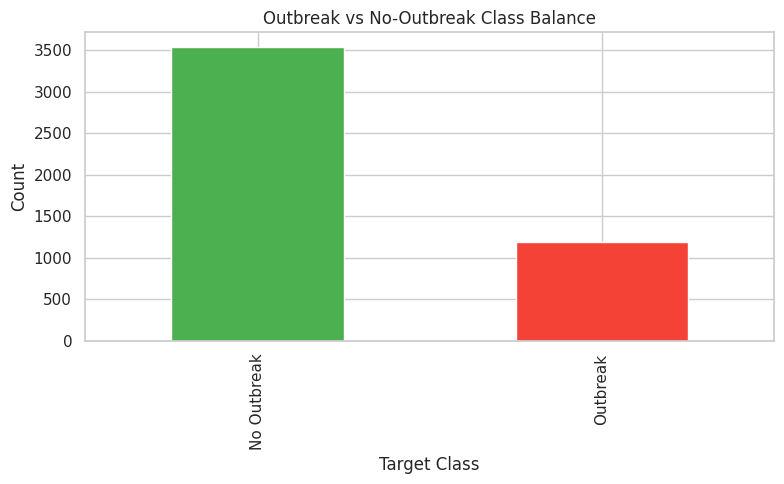

Saved figure: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/figures/average_monthly_cases.png


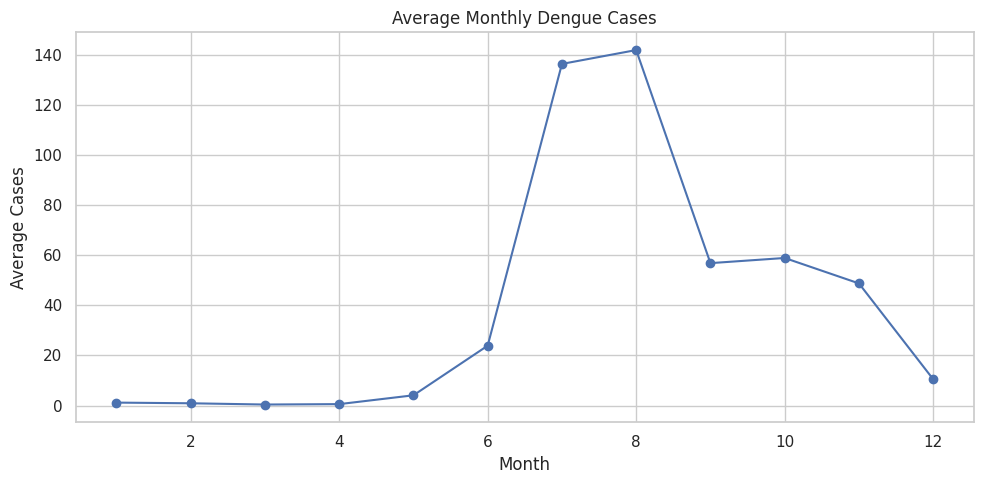

Saved figure: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/figures/correlation_heatmap.png


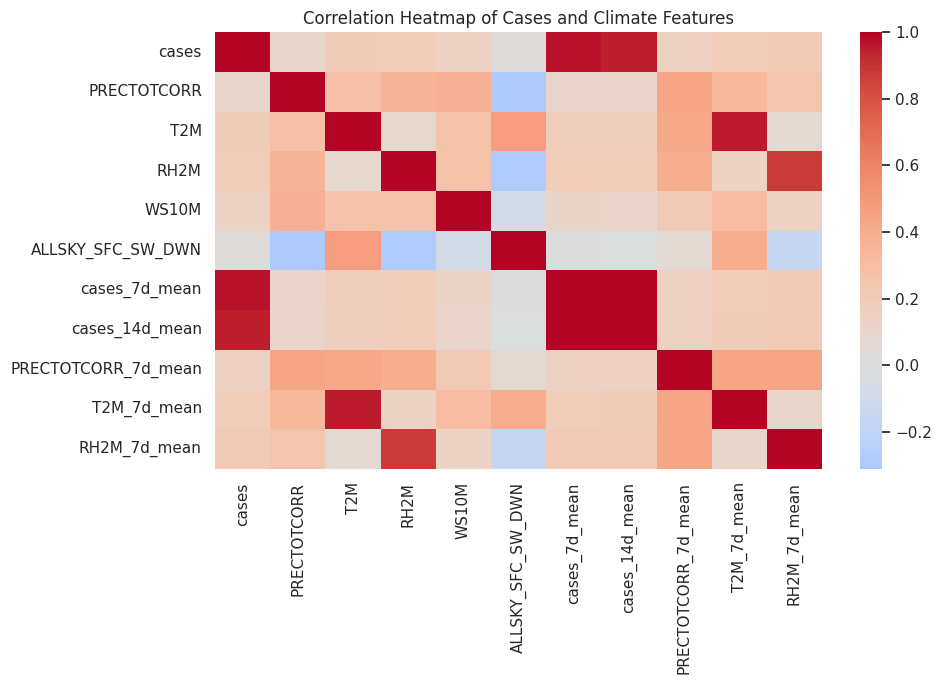

In [8]:

# 8. Exploratory visualizations


# Target class balance
fig = plt.figure(figsize=(8, 5))
df["target"].map(target_map).value_counts().plot(kind="bar", color=["#4CAF50", "#F44336"])
plt.title("Outbreak vs No-Outbreak Class Balance")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.tight_layout()
save_figure(fig, "target_class_balance")
plt.show()

# Monthly average dengue cases
monthly_cases = df.groupby("month")["cases"].mean()
fig = plt.figure(figsize=(10, 5))
monthly_cases.plot(marker="o")
plt.title("Average Monthly Dengue Cases")
plt.xlabel("Month")
plt.ylabel("Average Cases")
plt.tight_layout()
save_figure(fig, "average_monthly_cases")
plt.show()

# Correlation heatmap
corr_cols = [
    "cases", "PRECTOTCORR", "T2M", "RH2M", "WS10M", "ALLSKY_SFC_SW_DWN",
    "cases_7d_mean", "cases_14d_mean",
    "PRECTOTCORR_7d_mean", "T2M_7d_mean", "RH2M_7d_mean"
]
fig = plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Cases and Climate Features")
plt.tight_layout()
save_figure(fig, "correlation_heatmap")
plt.show()



## Multiple models instead of only one

A stronger academic notebook compares several models rather than assuming one method is best from the beginning.

Here we compare:

- Logistic Regression
- Random Forest
- HistGradientBoosting
- MLP

Then we select the best-performing model using **F1 score**, which is especially useful when class balance is imperfect.


In [9]:
# 9. Train-test split and preprocessing

feature_cols = [
    "district", "latitude", "longitude", "month", "weekofyear", "year", "dayofyear",
    "cases_lag_1", "cases_lag_7", "cases_7d_mean", "cases_14d_mean",
    "PRECTOTCORR", "T2M", "T2M_MAX", "T2M_MIN", "RH2M", "WS10M", "ALLSKY_SFC_SW_DWN",
    "PRECTOTCORR_7d_mean", "PRECTOTCORR_14d_mean",
    "T2M_7d_mean", "T2M_14d_mean",
    "RH2M_7d_mean", "RH2M_14d_mean",
    "WS10M_7d_mean", "WS10M_14d_mean",
    "ALLSKY_SFC_SW_DWN_7d_mean", "ALLSKY_SFC_SW_DWN_14d_mean"
]

X = df[feature_cols].copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

categorical_cols = ["district"]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_cols),
    ]
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (3782, 28)
Test shape : (946, 28)


In [10]:

# 10. Train multiple models and compare them


models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        max_iter=300,
        random_state=RANDOM_STATE
    )
}

results = []
trained_pipelines = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        probs = pipe.predict_proba(X_test)[:, 1]
    else:
        probs = None

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs) if probs is not None else np.nan

    results.append({
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    })

    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)


Training LogisticRegression...
Training RandomForest...
Training HistGradientBoosting...
Training MLP...


,model,accuracy,precision,recall,f1,roc_auc
0,MLP,0.980973,0.970085,0.953782,0.961864,0.997537
1,RandomForest,0.978858,0.973913,0.941176,0.957265,0.997834
2,HistGradientBoosting,0.977801,0.961702,0.949580,0.955603,0.998635
3,LogisticRegression,0.935518,0.904110,0.831933,0.866521,0.982849


Saved figure: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/figures/model_comparison_fullscale.png


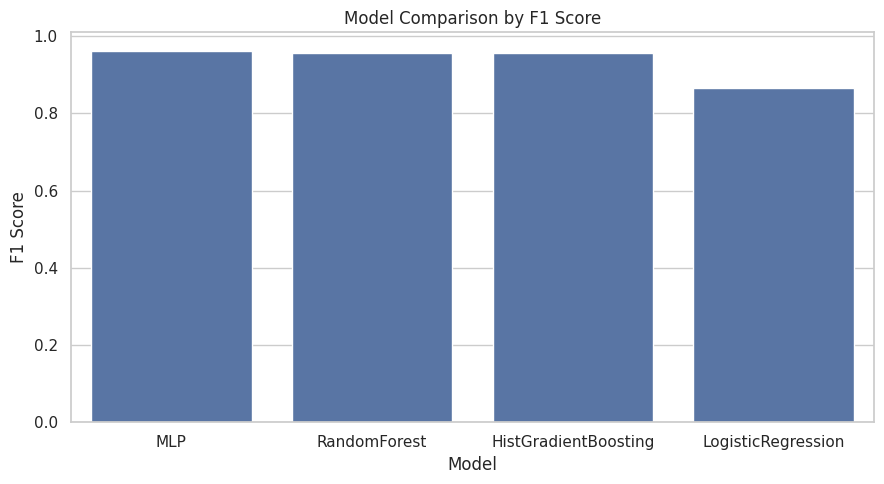

Saved figure: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/figures/model_comparison_zoomed.png


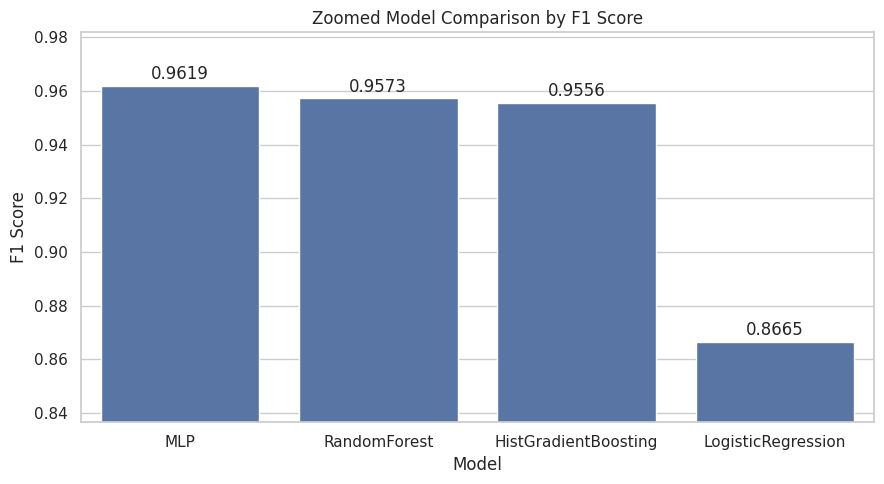

In [11]:

# 11. Model comparison plots


# Full-scale plot
fig = plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="model", y="f1")
plt.title("Model Comparison by F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.tight_layout()
save_figure(fig, "model_comparison_fullscale")
plt.show()

# Zoomed plot for small differences
ymin = max(0, results_df["f1"].min() - 0.03)
ymax = min(1.0, results_df["f1"].max() + 0.02)

fig = plt.figure(figsize=(9, 5))
ax = sns.barplot(data=results_df, x="model", y="f1")
plt.ylim(ymin, ymax)
plt.title("Zoomed Model Comparison by F1 Score")
plt.ylabel("F1 Score")
plt.xlabel("Model")

for i, row in results_df.iterrows():
    ax.text(i, row["f1"] + 0.001, f"{row['f1']:.4f}", ha="center", va="bottom")

plt.tight_layout()
save_figure(fig, "model_comparison_zoomed")
plt.show()



## Best model selection and artifact saving

The best model is selected automatically and saved as a **full pipeline**. That means preprocessing and modeling stay connected in one reusable object, which is exactly what we want for a stable deployment later.


In [12]:

# 12. Save best pipeline and metadata


best_model_name = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model selected:", best_model_name)

joblib.dump(best_pipeline, ARTIFACT_DIR / "best_dengue_pipeline.pkl")
joblib.dump(feature_cols, ARTIFACT_DIR / "feature_columns.pkl")

results_df.to_csv(REPORT_DIR / "model_comparison_metrics.csv", index=False)

with open(REPORT_DIR / "best_model_info.json", "w") as f:
    json.dump({
        "best_model_name": best_model_name,
        "generated_at": datetime.now().isoformat(),
        "feature_count": len(feature_cols),
        "dataset_page_url": DATASET_PAGE_URL,
        "nasa_power_docs_url": "https://power.larc.nasa.gov/docs/services/api/temporal/daily/"
    }, f, indent=2)

print("Saved best pipeline and metadata successfully.")


Best model selected: MLP
Saved best pipeline and metadata successfully.


Saved figure: /content/drive/MyDrive/Dengue_Forecasting_Project_Adust/figures/confusion_matrix_best_model.png


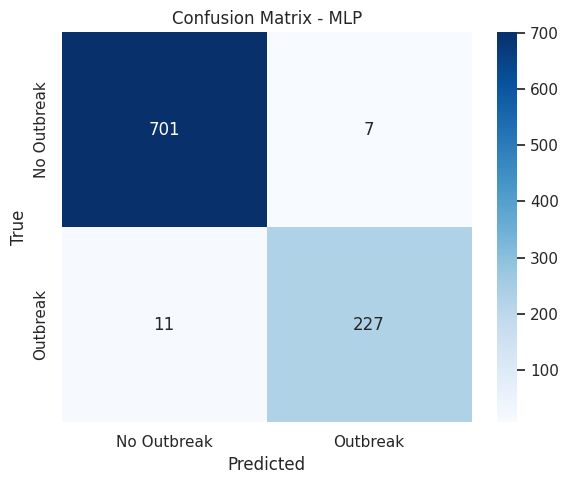

,precision,recall,f1-score,support
No Outbreak,0.984551,0.990113,0.987324,708.000000
Outbreak,0.970085,0.953782,0.961864,238.000000
accuracy,0.980973,0.980973,0.980973,0.980973
macro avg,0.977318,0.971947,0.974594,946.000000
weighted avg,0.980911,0.980973,0.980919,946.000000


In [13]:

# 13. Final evaluation


final_preds = best_pipeline.predict(X_test)

if hasattr(best_pipeline, "predict_proba"):
    final_probs = best_pipeline.predict_proba(X_test)[:, 1]
else:
    final_probs = None

report = classification_report(
    y_test,
    final_preds,
    target_names=["No Outbreak", "Outbreak"],
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(REPORT_DIR / "classification_report.csv")

cm = confusion_matrix(y_test, final_preds)

fig = plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Outbreak", "Outbreak"],
            yticklabels=["No Outbreak", "Outbreak"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
save_figure(fig, "confusion_matrix_best_model")
plt.show()

display(report_df)



## Standalone Gradio deployment

After the first full run, we should be able to reopen the notebook later, mount Drive, run the deployment cell below, and use the interface without retraining.

That is possible because the full saved pipeline is reused directly from Drive.


In [5]:
# Gradio UI for Dengue Forecasting
from google.colab import drive
drive.mount('/content/drive')
import joblib
import pandas as pd
import gradio as gr
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/Dengue_Forecasting_Project_Adust')
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'

best_pipeline = joblib.load(ARTIFACT_DIR / "best_dengue_pipeline.pkl")

district_choices = [
    "Dhaka", "Chattogram", "Khulna", "Rangpur",
    "Barishal", "Sylhet", "Mymensingh", "Rajshahi"
]

example_data = [
    ["Dhaka", 23.81, 90.41, 8, 34, 2023, 239, 500, 450, 480, 400, 10.5, 28.5, 32.0, 25.0, 85.0, 2.5, 15.0, 8.0, 7.5, 28.0, 27.5, 82.0, 80.0, 2.2, 2.1, 14.0, 13.5],
    ["Dhaka", 23.81, 90.41, 1, 3, 2023, 20, 0, 0, 0, 0, 0.0, 18.0, 22.0, 12.0, 50.0, 1.5, 12.0, 0.0, 0.0, 18.5, 19.0, 52.0, 55.0, 1.8, 1.7, 11.5, 11.0]
]

def predict_dengue_outbreak(
    district, latitude, longitude, month, weekofyear, year, dayofyear,
    cases_lag_1, cases_lag_7, cases_7d_mean, cases_14d_mean,
    PRECTOTCORR, T2M, T2M_MAX, T2M_MIN, RH2M, WS10M, ALLSKY_SFC_SW_DWN,
    PRECTOTCORR_7d_mean, PRECTOTCORR_14d_mean,
    T2M_7d_mean, T2M_14d_mean,
    RH2M_7d_mean, RH2M_14d_mean,
    WS10M_7d_mean, WS10M_14d_mean,
    ALLSKY_SFC_SW_DWN_7d_mean, ALLSKY_SFC_SW_DWN_14d_mean
):
    row = pd.DataFrame([{
        "district": district,
        "latitude": float(latitude),
        "longitude": float(longitude),
        "month": int(month),
        "weekofyear": int(weekofyear),
        "year": int(year),
        "dayofyear": int(dayofyear),
        "cases_lag_1": float(cases_lag_1),
        "cases_lag_7": float(cases_lag_7),
        "cases_7d_mean": float(cases_7d_mean),
        "cases_14d_mean": float(cases_14d_mean),
        "PRECTOTCORR": float(PRECTOTCORR),
        "T2M": float(T2M),
        "T2M_MAX": float(T2M_MAX),
        "T2M_MIN": float(T2M_MIN),
        "RH2M": float(RH2M),
        "WS10M": float(WS10M),
        "ALLSKY_SFC_SW_DWN": float(ALLSKY_SFC_SW_DWN),
        "PRECTOTCORR_7d_mean": float(PRECTOTCORR_7d_mean),
        "PRECTOTCORR_14d_mean": float(PRECTOTCORR_14d_mean),
        "T2M_7d_mean": float(T2M_7d_mean),
        "T2M_14d_mean": float(T2M_14d_mean),
        "RH2M_7d_mean": float(RH2M_7d_mean),
        "RH2M_14d_mean": float(RH2M_14d_mean),
        "WS10M_7d_mean": float(WS10M_7d_mean),
        "WS10M_14d_mean": float(WS10M_14d_mean),
        "ALLSKY_SFC_SW_DWN_7d_mean": float(ALLSKY_SFC_SW_DWN_7d_mean),
        "ALLSKY_SFC_SW_DWN_14d_mean": float(ALLSKY_SFC_SW_DWN_14d_mean),
    }])

    pred = int(best_pipeline.predict(row)[0])

    prob_text = "Probability not available"
    if hasattr(best_pipeline, "predict_proba"):
        try:
            prob = float(best_pipeline.predict_proba(row)[0, 1])
            prob_text = f"Probability: {prob:.2%}"
        except Exception as e:
            prob_text = f"Probability unavailable: {str(e)}"

    label = "Outbreak Risk" if pred == 1 else "No Outbreak Risk"

    if pred == 1:
        recommendation = (
            "Recommendation:\n"
            "- Increase surveillance\n"
            "- Monitor hotspots\n"
            "- Prepare clinical response\n"
            "- Recheck with latest weekly data"
        )
    else:
        recommendation = (
            "Recommendation:\n"
            "- Maintain routine surveillance\n"
            "- Continue prevention measures\n"
            "- Monitor trend weekly\n"
            "- Update forecast regularly"
        )

    return f"{label}\n{prob_text}", recommendation

custom_css = """
.gradio-container {
    max-width: 1250px !important;
    margin: auto !important;
}
.hero {
    background: linear-gradient(135deg, #0f172a, #0f766e, #2563eb);
    color: white;
    padding: 24px;
    border-radius: 20px;
    margin-bottom: 16px;
}
"""

theme = gr.themes.Soft()

with gr.Blocks(theme=theme, css=custom_css) as demo:
    gr.HTML("""
    <div class="hero">
        <h1 style="margin:0;">Dengue Outbreak Forecasting</h1>
        <p style="margin:10px 0 0 0;">
            Md. Maruf Ahammad Bhuiyan
        </p>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=2):
            district = gr.Dropdown(district_choices, label="District", value="Dhaka")

            with gr.Row():
                latitude = gr.Number(label="Latitude", value=23.81)
                longitude = gr.Number(label="Longitude", value=90.41)

            with gr.Row():
                month = gr.Slider(1, 12, value=1, step=1, label="Month")
                weekofyear = gr.Slider(1, 53, value=3, step=1, label="Week of Year")
                year = gr.Slider(2020, 2035, value=2023, step=1, label="Year")
                dayofyear = gr.Slider(1, 366, value=20, step=1, label="Day of Year")

            with gr.Accordion("Historical Case Features", open=True):
                with gr.Row():
                    cases_lag_1 = gr.Number(label="Cases Lag 1", value=0)
                    cases_lag_7 = gr.Number(label="Cases Lag 7", value=0)
                    cases_7d_mean = gr.Number(label="Cases 7-Day Mean", value=0)
                    cases_14d_mean = gr.Number(label="Cases 14-Day Mean", value=0)

            with gr.Accordion("Current Weather Features", open=False):
                with gr.Row():
                    PRECTOTCORR = gr.Number(label="Precipitation", value=0.0)
                    T2M = gr.Number(label="Temperature", value=18.0)
                    T2M_MAX = gr.Number(label="Temperature Max", value=22.0)
                    T2M_MIN = gr.Number(label="Temperature Min", value=12.0)

                with gr.Row():
                    RH2M = gr.Number(label="Relative Humidity", value=50.0)
                    WS10M = gr.Number(label="Wind Speed", value=1.5)
                    ALLSKY_SFC_SW_DWN = gr.Number(label="Solar Radiation", value=12.0)

            with gr.Accordion("Rolling Weather Averages", open=False):
                with gr.Row():
                    PRECTOTCORR_7d_mean = gr.Number(label="Precipitation 7-Day Mean", value=0.0)
                    PRECTOTCORR_14d_mean = gr.Number(label="Precipitation 14-Day Mean", value=0.0)

                with gr.Row():
                    T2M_7d_mean = gr.Number(label="Temperature 7-Day Mean", value=18.5)
                    T2M_14d_mean = gr.Number(label="Temperature 14-Day Mean", value=19.0)

                with gr.Row():
                    RH2M_7d_mean = gr.Number(label="Humidity 7-Day Mean", value=52.0)
                    RH2M_14d_mean = gr.Number(label="Humidity 14-Day Mean", value=55.0)

                with gr.Row():
                    WS10M_7d_mean = gr.Number(label="Wind Speed 7-Day Mean", value=1.8)
                    WS10M_14d_mean = gr.Number(label="Wind Speed 14-Day Mean", value=1.7)

                with gr.Row():
                    ALLSKY_SFC_SW_DWN_7d_mean = gr.Number(label="Solar 7-Day Mean", value=11.5)
                    ALLSKY_SFC_SW_DWN_14d_mean = gr.Number(label="Solar 14-Day Mean", value=11.0)

            predict_btn = gr.Button("Predict Outbreak Risk", variant="primary")

            inputs = [
                district, latitude, longitude, month, weekofyear, year, dayofyear,
                cases_lag_1, cases_lag_7, cases_7d_mean, cases_14d_mean,
                PRECTOTCORR, T2M, T2M_MAX, T2M_MIN, RH2M, WS10M, ALLSKY_SFC_SW_DWN,
                PRECTOTCORR_7d_mean, PRECTOTCORR_14d_mean,
                T2M_7d_mean, T2M_14d_mean,
                RH2M_7d_mean, RH2M_14d_mean,
                WS10M_7d_mean, WS10M_14d_mean,
                ALLSKY_SFC_SW_DWN_7d_mean, ALLSKY_SFC_SW_DWN_14d_mean
            ]

            gr.Examples(examples=example_data, inputs=inputs)

        with gr.Column(scale=1):
            prediction_output = gr.Textbox(label="Prediction", lines=4)
            recommendation_output = gr.Textbox(label="Recommendation", lines=6)

    predict_btn.click(
        fn=predict_dengue_outbreak,
        inputs=inputs,
        outputs=[prediction_output, recommendation_output],
        show_progress="full"
    )

demo.launch(
    share=True,
    inline=True,
    debug=True,
    show_error=True
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1960/1718018147.py:112: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=custom_css) as demo:
/tmp/ipykernel_1960/1718018147.py:112: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=custom_css) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6c96051d134b6d2e4a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6c96051d134b6d2e4a.gradio.live
